In [1]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [2]:
from torch.utils.data import DataLoader
# 학습할 때 매 epoch마다 데이터를 64개씩 랜덤한 순서로 꺼내도록 설정
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# train_loader를 반복자(iterator)로 바꿉니다. next()를 사용해서 배치를 하나씩 직접 꺼낼 수 있음
data_iter = iter(train_loader)
# DataLoader는 (입력 데이터, 정답 라벨) 형태로 데이터를 반환한다.
images, labels = next(data_iter)    # next() 첫 번째 배치를 꺼냅니다.
print(f"배치 이미지의 shape: {images.shape}")   # [배치크기, 채널수, 높이, 너비]

배치 이미지의 shape: torch.Size([64, 1, 28, 28])


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1 모델 정의
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        # 2차원 이미지 데이터를 1차원 벡터로 평탄화(flatten)
        x = x.view(-1, 28*28)   # -1 : 배치 크기 자동 계산
        return self.fc(x)

# 2 데이터 전처리
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307, ), (0.2081,)) # MNIST 평균 및 표준 편차
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 3 모델, 손실 함수, 옵티마이저 설정
model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4 학습 루프
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()                   # 이전 기울기 초기화
        outputs = model(images)                 # 순전파: 예측값 계산
        loss = criterion(outputs, labels)       # 손실 계산
        loss.backward()                         # 역전파: 기울기 계산
        optimizer.step()                        # 파라미터 업데이트
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

# 5 평가 함수 정의 및 테스트 데이터셋 평가
def evaluate(model, data_loader):
    model.eval()    # 평가 모드로 전환
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

test_accuracy = evaluate(model, test_loader)
print(f"Test Accuracy: {test_accuracy:2f}%")

Epoch 1/5, Loss: 0.2373
Epoch 2/5, Loss: 0.1056
Epoch 3/5, Loss: 0.0731
Epoch 4/5, Loss: 0.0563
Epoch 5/5, Loss: 0.0454
Test Accuracy: 97.590000%


사용 디바이스: xpu


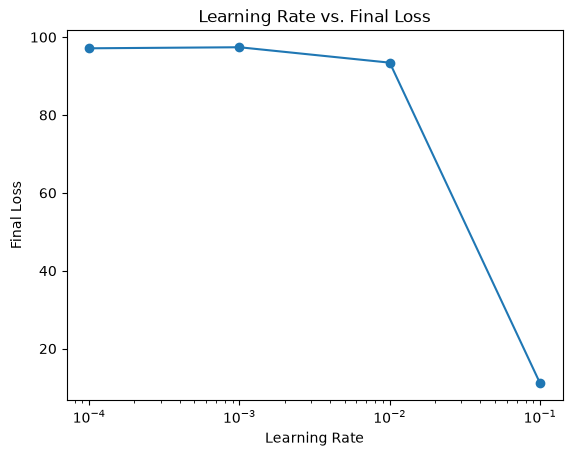

In [8]:
import matplotlib.pyplot as plt
import torch.optim as optim

device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print("사용 디바이스:", device)

def evaluateWithDevice(model, data_loader, device):
    model.eval()    # 평가 모드로 전환
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

learning_rates = [0.1, 0.01, 0.001, 0.0001]
final_losses = []

for lr in learning_rates:
    model = SimpleMLP().to(device)      # 모델을 xpu로 이동
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(10):
        model.train()
        for images, labels in train_loader:
            images = images.to(device)  # 입력 데이터를 xpu로 이동
            labels = labels.to(device)  # 정답 데이터를 xpu로 이동

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    # 테스트 데이터셋을 이용하여 모델 평가 (평균 손실 기록)
    loss_avg = evaluateWithDevice(model, test_loader, device)
    final_losses.append(loss_avg)

plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Learning Rate vs. Final Loss")
plt.xscale('log')
plt.show()